<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/TNS1_Ex5_Tuningcurves_RFs/TNS_I_Exercise_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tuning curves and receptive fields

## Introduction
This exercise simulates neurophysiological experiments in the visual cortex of cat.   You will simulate visually (with images) and collect neuronal responses.  By comparing the responses to different kinds of stimuli, you will characterise the responsiveness or stimulus selectivity of each neurone.  Your specific goals are to map the receptive fields and to establish some tuning curves of your neurones.


## Provided functions

You are provided with two Python classes - *MysteriousNeuron1()* and *MysteriousNeuron2()* - which implement the behaviour of unknown V1 neurons. Each function requires as input a two-dimensional stimulus array $S$ and produces as output a scalar response $r$, i.e. the firing rate in Hz.
```python
OnSpot(n), OffSpot(n), OnBar(n, theta), OffBar(n, theta), WhiteNoise(n)
```

Were ```n``` and ```theta``` are the integer array size and the bar orientation in radians, respectively.

These functions produce a variety of stimulus arrays S, including ON-contrast spots, OFF-contrast spots, ON-contrast bars, OFF-contrast bars, and white noise.  

All stimulus functions produce a stochastic result, in other words, a different image each time the function is called: spots and bars change position, and white noise changes all pixel values.


## Assignment

Characterise the responsiveness of each neurone by stimulating with multiple images of size $n=50$ and by collecting the resulting responses.   Note that you have to adjust the number of stimulus repetitions such as to obtain a valid result.  White noise stimulation will have to be repeated more often than dot or bar stimulation.


* Stimulating repeatedly ($n$ times) with **bright bars** (*OnBar*) with one particular orientation $\theta$, establish the average response $\langle{r(\theta)} \rangle$, average square response $\langle{r^2(\theta)}\rangle$, and standard deviation of the response $\sigma_r(\theta)$ to bars of this orientation!  Repeat for approximately 12 different orientations to establish a 'tuning curve':

\\
$$
\langle{ r(\theta)}\rangle = \frac{1}{n} \sum_{i=1}^n \, r_i, \qquad\qquad\langle{ r^2(\theta)}\rangle = \frac{1}{n} \sum_{i=1}^n \, r_i^2, \qquad\qquad \sigma_r(\theta) = \sqrt{\langle{r^2}\rangle - \langle{r}\rangle^2}
$$
Plot the average response $\langle{ r(\theta)}\rangle$, average plus standard deviation $\langle{ r(\theta)}\rangle+c_v(\theta)$, and average minus standard deviation $\langle{ r(\theta)}\rangle+c_v(\theta)$, as a function of $\theta$.   What do you conclude about the response properties of each neurone?

* Repeat all steps with **dark bars**  (*OffBar*).

* Stimulating repeatedly ($k$ times) with **bright spots**  (*OnSpot*) at varying positions and obtain the response-weighted average of the stimulus images!   In other words, combine stimulus images $S_i$ and associated responsse $r_i$ according to the formula

\\
$$
\bar S = \frac{\sum_{i=1}^k \, S_i \, r_i}{\sum_{i=1}^k \, r_i}
$$
Plot the resulting average image, for example using pcolor, and discuss your conclusions for both neurons.

* Repeat with **dark spots** (*OffSpot*) and with **white noise** (*WhiteNoise*)!   Plot the resulting average images and discuss your conclusions, not in in particular any differences between stimulus types and between the two neurones.

* Discuss the advantages and disadvantages of using different stimulus types. Consider the number of trials needed and the amount of detailed information gained.



## Optional assignment (advanced!)

Consider the possibility that one or both of your neuronal responses reflect more than one linear receptive field.  In this case, the computation of a response-weighted average will fail (i.e., show no structure).   However, the computation of a response-weighted {\bf covariance} may succeed, as the principal eigenvectors of this matrix may reveal the contributing receptive fields:

\\
$$
S_n \quad \text{stimulus pixel vector} \quad [n\cdot n,1]
$$

\\
$$
C_{nm} = S_n \cdot S_m \quad \text{stimulus covariance matrix} \quad [n\cdot n, n\cdot n]
$$

\\
$$
\bar S = \frac{\sum_i \, r_i \cdot S_i}{\sum_i \, r_i} \quad \text{response weighted average stimulus} \quad [n,n]
$$

\\
$$
\bar C_{nm} = \frac{\sum_i \, r_i \cdot C_{nm_i}}{\sum_i \, r_i} \quad \text{response weighted average covariance} \quad [n\cdot n, n\cdot n]
$$

where $i$ is an index over trials and $n$, $m$ are indices over stimulus pixels.

Obtain eigenvectors and eigenvalues of the weighted covariance matrix with the command:
```
D, V = np.linalg.eig(Cnm)
```
View the principal eigenvectors as receptive fields, using the function ```reshape()``` to sort the pixelvalues of the eigenvectors back into the stimulus area. What does the response-weighted covariance tell you about mysterious neuron 2?



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def MysteriousNeuron1(S):
    """
    A mysterious visual neuron is stimulated with a 2D stimulus
    array S and responds with a spike rate r (in spikes per second).
    """
    yh, xw = S.shape
    A = np.zeros((yh, xw))

    X, Y = np.meshgrid(-0.5*(yh+1) + np.arange(1, yh+1), -0.5*(xw+1) + np.arange(1, xw+1))
    A = 0.0016 * np.exp(-0.005 * (X**2 + Y**2)) * np.cos(0.433 * X + 0.25 * Y + 0.5)

    r = np.sum(A * S) / np.sum(A * A)

    if r < 0:
        r = 0

    r = r**3 / (0.3**2.5 + r**2.5)
    r = r + (0.1 + 0.1 * r) * np.random.randn()

    return r

def MysteriousNeuron2(S):
    """
    A mysterious visual neuron is stimulated with a 2D stimulus
    array S and responds with a spike rate r (in spikes per second).
    """
    yh, xw = S.shape
    A = np.zeros((yh, xw))

    X, Y = np.meshgrid(-0.5*(yh+1) + np.arange(1, yh+1), -0.5*(xw+1) + np.arange(1, xw+1))

    A = 0.0016 * np.exp(-0.005 * (X**2 + Y**2)) * np.cos(0.25 * X + 0.433 * Y + np.pi / 4.0)
    B = 0.0016 * np.exp(-0.005 * (X**2 + Y**2)) * np.cos(0.25 * X + 0.433 * Y + 3 * np.pi / 4.0)

    AA = np.sum(A * A)
    BB = np.sum(B * B)

    SA = np.sum(A * S)
    SB = np.sum(B * S)

    r = np.sqrt(SA**2 + SB**2) / np.sqrt(AA**2 + BB**2)

    if r < 0:
        r = 0

    r = r**3 / (0.3**2.5 + r**2.5)
    r = r + (0.1 + 0.1 * r) * np.random.randn()

    return r

def OnBar(n, theta):
    """
    Generates an 'OnBar' stimulus with orientation theta.
    """
    S = np.zeros((n, n))
    X, Y = np.meshgrid(-0.5*(n+1) + np.arange(1, n+1), -0.5*(n+1) + np.arange(1, n+1))
    S = np.exp(-0.5 * (np.cos(theta) * X + np.sin(theta) * Y + 0.1 * n * np.random.randn()) ** 2)
    return S

def OffBar(n, theta):
    """
    Generates an 'OffBar' stimulus with orientation theta.
    """
    S = np.zeros((n, n))
    X, Y = np.meshgrid(-0.5*(n+1) + np.arange(1, n+1), -0.5*(n+1) + np.arange(1, n+1))
    S = -np.exp(-0.5 * (np.cos(theta) * X + np.sin(theta) * Y + 0.1 * n * np.random.randn()) ** 2)
    return S

def OnSpot(n):
    """
    Generates an 'OnSpot' stimulus.
    """
    S = np.zeros((n, n))
    x = np.arange(-0.5 * (n + 1), 0.5 * (n + 1))
    y = np.arange(-0.5 * (n + 1), 0.5 * (n + 1))
    X, Y = np.meshgrid(x, y)
    x0 = 0.8 * (np.random.rand() - 0.5) * n
    y0 = 0.8 * (np.random.rand() - 0.5) * n
    S = np.exp(-0.5 * ((X - x0) ** 2 + (Y - y0) ** 2))
    return S

def OffSpot(n):
    """
    Generates an 'OffSpot' stimulus.
    """
    S = np.zeros((n, n))
    x = np.arange(-0.5 * (n + 1), 0.5 * (n + 1))
    y = np.arange(-0.5 * (n + 1), 0.5 * (n + 1))
    X, Y = np.meshgrid(x, y)
    x0 = 0.8 * (np.random.rand() - 0.5) * n
    y0 = 0.8 * (np.random.rand() - 0.5) * n
    S = 1 - np.exp(-0.5 * ((X - x0) ** 2 + (Y - y0) ** 2))
    return S

def WhiteNoise(n):
    """
    Generates white noise from a normal distribution.
    """
    s = np.random.normal(0, 1, (n, n))
    return s


Characterise the responsiveness of each neurone by stimulating with multiple images of size n=50 and by collecting the resulting responses. Note that you have to adjust the number of stimulus repetitions such as to obtain a valid result. White noise stimulation will have to be repeated more often than dot or bar stimulation.


Stimulating repeatedly (n times) with bright bars (OnBar) with one particular orientation θ, establish the average response ⟨r(θ)⟩, average square response ⟨r2(θ)⟩, and standard deviation of the response σr(θ) to bars of this orientation! Repeat for approximately 12 different orientations to establish a 'tuning curve':


In [ ]:
# create a vector containing rotations between 180 degrees, converted to radians
rotationVector = np.radians(np.linspace(0,180, 12))
# number of repeats for testing the mystery neurons
nRepeats = 600
onBarMeanVectorMN1 = []
onBarSTDVectorMN1 = []
onBarSquareVectorMN1 = []
onBarMeanVectorMN2 = []
onBarSTDVectorMN2 = []
onBarSquareVectorMN2 = []
offBarMeanVectorMN1 = []
offBarSTDVectorMN1 = []
offBarSquareVectorMN1 = []
offBarMeanVectorMN2 = []
offBarSTDVectorMN2 = []
offBarSquareVectorMN2 = []
for rot in rotationVector:
  onBarResponseVectorMN1 = []
  onBarResponseVectorMN2 = []
  offBarResponseVectorMN1 = []
  offBarResponseVectorMN2 = []
  for j in range(nRepeats):
    # generate an on bar image
    onBarImage = OnBar(50, rot)
    # calculate the Mystery neuron 1 response to on bar
    onBarMN1Response = MysteriousNeuron1(onBarImage)
    onBarResponseVectorMN1.append(onBarMN1Response)
    # calculate the Mystery neuron 2 response to on bar
    onBarMN2Response = MysteriousNeuron2(onBarImage)
    onBarResponseVectorMN2.append(onBarMN2Response)
    # generate an off bar image
    offBarImage = OffBar(50, rot)
    # calculate the Mystery neuron 1 response to on bar
    offBarMN1Response = MysteriousNeuron1(offBarImage)
    offBarResponseVectorMN1.append(offBarMN1Response)
    # calculate the Mystery neuron 2 response to on bar
    offBarMN2Response = MysteriousNeuron2(offBarImage)
    offBarResponseVectorMN2.append(offBarMN2Response)
  # calculate the mean response, std of response, and mean of squared response
  onBarMeanVectorMN1.append(np.mean(onBarResponseVectorMN1))
  onBarSTDVectorMN1.append(np.std(onBarResponseVectorMN1))
  onBarSquareVectorMN1.append(np.mean(np.array(onBarResponseVectorMN1)**2))
  onBarMeanVectorMN2.append(np.mean(onBarResponseVectorMN2))
  onBarSTDVectorMN2.append(np.std(onBarResponseVectorMN2))
  onBarSquareVectorMN2.append(np.mean(np.array(onBarResponseVectorMN2)**2))
  offBarMeanVectorMN1.append(np.mean(offBarResponseVectorMN1))
  offBarSTDVectorMN1.append(np.std(offBarResponseVectorMN1))
  offBarSquareVectorMN1.append(np.mean(np.array(offBarResponseVectorMN1)**2))
  offBarMeanVectorMN2.append(np.mean(offBarResponseVectorMN2))
  offBarSTDVectorMN2.append(np.std(offBarResponseVectorMN2))
  offBarSquareVectorMN2.append(np.mean(np.array(offBarResponseVectorMN2)**2))

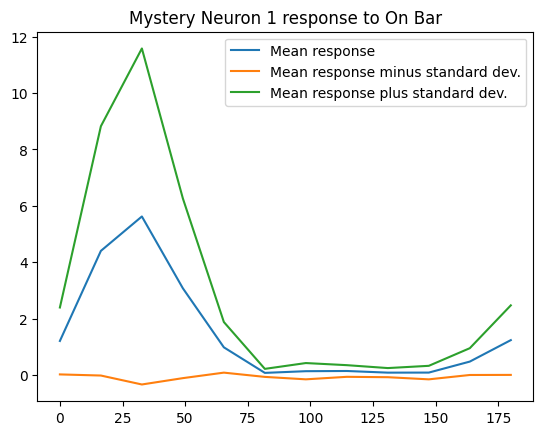

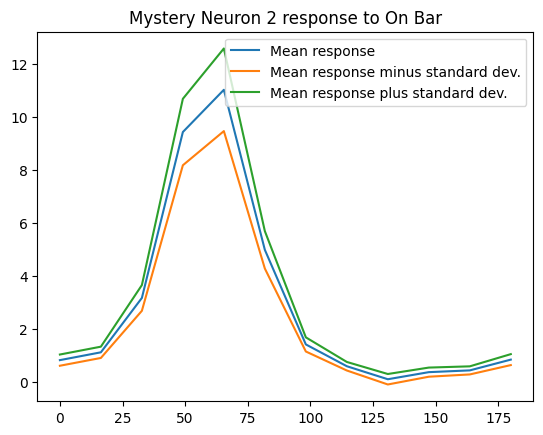

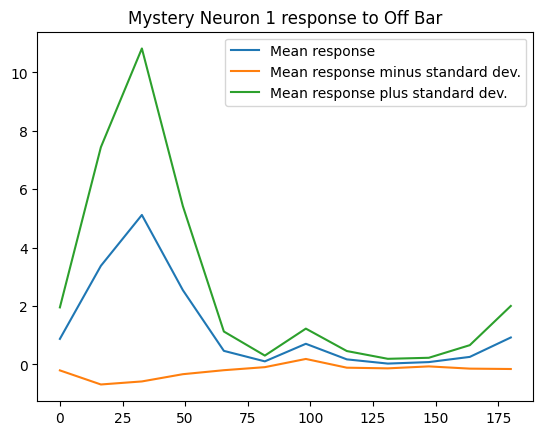

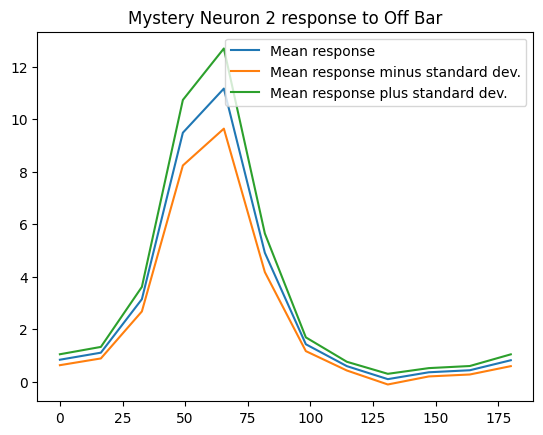

In [ ]:
# Plotting the tuning curves
plt.plot(np.linspace(0,180, 12), onBarMeanVectorMN1, label='Mean response')
plt.plot(np.linspace(0,180, 12), np.array(onBarMeanVectorMN1) - np.array(onBarSTDVectorMN1), label='Mean response minus standard dev.')
plt.plot(np.linspace(0,180, 12), np.array(onBarMeanVectorMN1) + np.array(onBarSTDVectorMN1), label='Mean response plus standard dev.')
plt.legend(loc='upper right')
plt.title('Mystery Neuron 1 response to On Bar')
plt.show()
plt.plot(np.linspace(0,180, 12), onBarMeanVectorMN2, label='Mean response')
plt.plot(np.linspace(0,180, 12), np.array(onBarMeanVectorMN2) - np.array(onBarSTDVectorMN2), label='Mean response minus standard dev.')
plt.plot(np.linspace(0,180, 12), np.array(onBarMeanVectorMN2) + np.array(onBarSTDVectorMN2), label='Mean response plus standard dev.')
plt.legend(loc='upper right')
plt.title('Mystery Neuron 2 response to On Bar')
plt.show()
plt.plot(np.linspace(0,180, 12), offBarMeanVectorMN1, label='Mean response')
plt.plot(np.linspace(0,180, 12), np.array(offBarMeanVectorMN1) - np.array(offBarSTDVectorMN1), label='Mean response minus standard dev.')
plt.plot(np.linspace(0,180, 12), np.array(offBarMeanVectorMN1) + np.array(offBarSTDVectorMN1), label='Mean response plus standard dev.')
plt.legend(loc='upper right')
plt.title('Mystery Neuron 1 response to Off Bar')
plt.show()
plt.plot(np.linspace(0,180, 12), offBarMeanVectorMN2, label='Mean response')
plt.plot(np.linspace(0,180, 12), np.array(offBarMeanVectorMN2) - np.array(offBarSTDVectorMN2), label='Mean response minus standard dev.')
plt.plot(np.linspace(0,180, 12), np.array(offBarMeanVectorMN2) + np.array(offBarSTDVectorMN2), label='Mean response plus standard dev.')
plt.legend(loc='upper right')
plt.title('Mystery Neuron 2 response to Off Bar')
plt.show()


Stimulating repeatedly (k times) with bright spots (OnSpot) at varying positions and obtain the response-weighted average of the stimulus images! In other words, combine stimulus images Si and associated responsse ri according to the formula


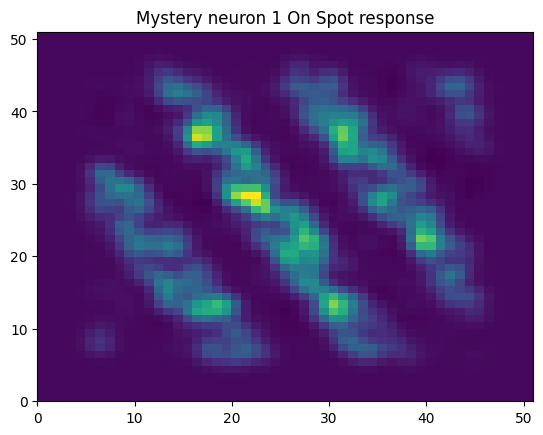

14.932890934720294


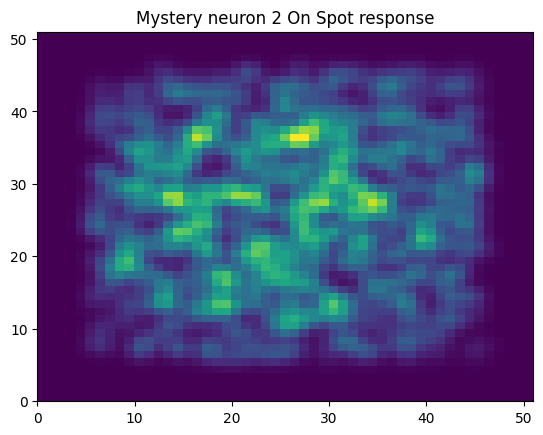

In [ ]:
# generate an image to create a zero array based on
onSpotImage = OnSpot(50)
# create empty array to store responses
onSpotResponseVectorMN1 = np.zeros_like(onSpotImage)
onSpotResponseVectorMN2 = np.zeros_like(onSpotImage)
# generate repeated responses to On Spot for both neurons and calculate the
for k in range(nRepeats):
  onSpotImage = OnSpot(50)
  onSpotResponseMN1 = MysteriousNeuron1(onSpotImage)
  onSpotResponseMN2 = MysteriousNeuron2(onSpotImage)
  # calculated response weighted average stimulus for each neuron
  onSpotResponseVectorMN1 = onSpotResponseVectorMN1 + (onSpotImage * onSpotResponseMN1)
  onSpotResponseVectorMN2 = onSpotResponseVectorMN2 + (onSpotImage * onSpotResponseMN2)
# plot the responses as arrays
plt.pcolor(onSpotResponseVectorMN1)
plt.title('Mystery neuron 1 On Spot response')
plt.show()
print(np.max(onSpotResponseVectorMN1))
plt.pcolor(onSpotResponseVectorMN2)
plt.title('Mystery neuron 2 On Spot response')
plt.show()

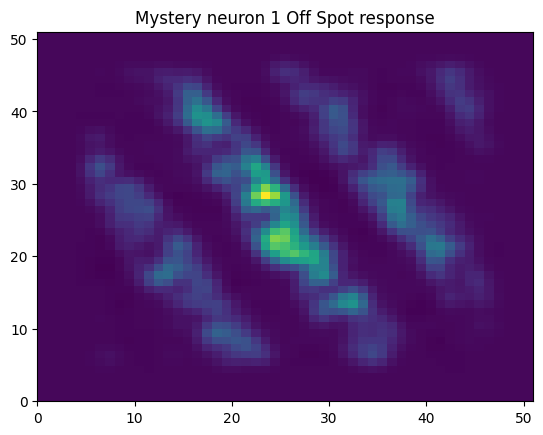

25.977494399429624


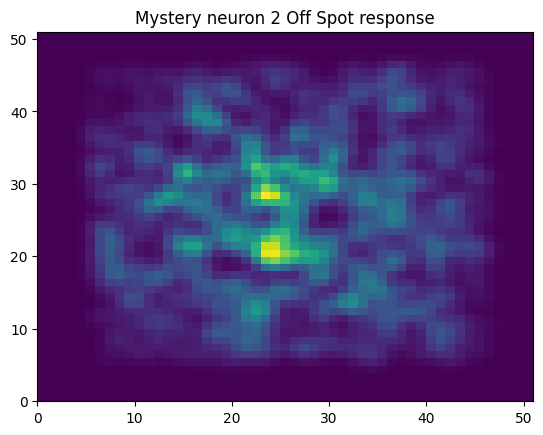

25.6165179899311


In [ ]:
# same as above but with off spot
offSpotImage = OnSpot(50)
offSpotResponseVectorMN1 = np.zeros_like(offSpotImage)
offSpotResponseVectorMN2 = np.zeros_like(offSpotImage)
for k in range(nRepeats):
  offSpotImage = OnSpot(50)
  offSpotResponseMN1 = MysteriousNeuron1(offSpotImage)
  offSpotResponseMN2 = MysteriousNeuron2(offSpotImage)
  offSpotResponseVectorMN1 = offSpotResponseVectorMN1 + (offSpotImage * offSpotResponseMN1)
  offSpotResponseVectorMN2 = offSpotResponseVectorMN2 + (offSpotImage * offSpotResponseMN2)
plt.pcolor(offSpotResponseVectorMN1)
plt.title('Mystery neuron 1 Off Spot response')
plt.show()
print(np.max(offSpotResponseVectorMN1))
plt.pcolor(offSpotResponseVectorMN2)
plt.title('Mystery neuron 2 Off Spot response')
plt.show()
print(np.max(offSpotResponseVectorMN2))

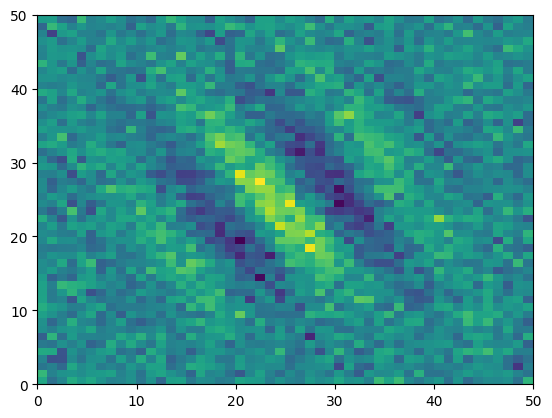

1901.545963320273


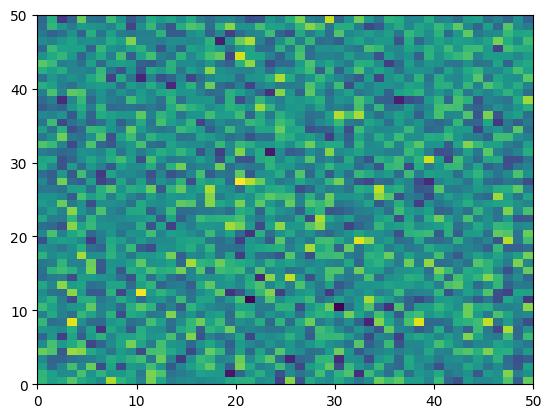

1574.819875898073


In [ ]:
# same as above but with white noice
# increased number of repeats to help expose the pattern using white noise
nRepeats = 5000
whiteNoiseImage = WhiteNoise(50)
whiteNoiseResponseVectorMN1 = np.zeros_like(whiteNoiseImage)
whiteNoiseResponseVectorMN2 = np.zeros_like(whiteNoiseImage)
for k in range(nRepeats):
  whiteNoiseImage = WhiteNoise(50)
  whiteNoiseResponseMN1 = MysteriousNeuron1(whiteNoiseImage)
  whiteNoiseResponseMN2 = MysteriousNeuron2(whiteNoiseImage)
  whiteNoiseResponseVectorMN1 = whiteNoiseResponseVectorMN1 + (whiteNoiseImage * whiteNoiseResponseMN1)
  whiteNoiseResponseVectorMN2 = whiteNoiseResponseVectorMN2 + (whiteNoiseImage * whiteNoiseResponseMN2)
plt.pcolor(whiteNoiseResponseVectorMN1)
plt.show()
print(np.max(whiteNoiseResponseVectorMN1))
plt.pcolor(whiteNoiseResponseVectorMN2)
plt.show()
print(np.max(whiteNoiseResponseVectorMN2))

## Optional assignment (advanced!)

Consider the possibility that one or both of your neuronal responses reflect more than one linear receptive field.  In this case, the computation of a response-weighted average will fail (i.e., show no structure).   However, the computation of a response-weighted {\bf covariance} may succeed, as the principal eigenvectors of this matrix may reveal the contributing receptive fields:

\\
$$
S_n \quad \text{stimulus pixel vector} \quad [n\cdot n,1]
$$

\\
$$
C_{nm} = S_n \cdot S_m \quad \text{stimulus covariance matrix} \quad [n\cdot n, n\cdot n]
$$

\\
$$
\bar S = \frac{\sum_i \, r_i \cdot S_i}{\sum_i \, r_i} \quad \text{response weighted average stimulus} \quad [n,n]
$$

\\
$$
\bar C_{nm} = \frac{\sum_i \, r_i \cdot C_{nm_i}}{\sum_i \, r_i} \quad \text{response weighted average covariance} \quad [n\cdot n, n\cdot n]
$$

where $i$ is an index over trials and $n$, $m$ are indices over stimulus pixels.

Obtain eigenvectors and eigenvalues of the weighted covariance matrix with the command:
```
D, V = np.linalg.eig(Cnm)
```
View the principal eigenvectors as receptive fields, using the function ```reshape()``` to sort the pixelvalues of the eigenvectors back into the stimulus area. What does the response-weighted covariance tell you about mysterious neuron 2?


In [ ]:
# calculate the response weighted average covariance using the on spot stimulus
r_mean = []
nRepeats = 600
C_nm_repeated = np.zeros([2500,2500])
for k in range(nRepeats):
  onSpotImage = OnSpot(49)
  r = MysteriousNeuron2(onSpotImage)
  r_mean.append(r)
  # reshape image into vector
  onBarImageVector = onSpotImage.reshape([50*50,1])
  C_nm = np.zeros([50*50,50*50])
  C_nm_mean = np.zeros([50*50,50*50])
  # calculate cross correlation
  C_nm = np.matmul(onBarImageVector, onBarImageVector.transpose())
  C_nm_mean = C_nm * r
  C_nm_repeated = C_nm_repeated + C_nm_mean


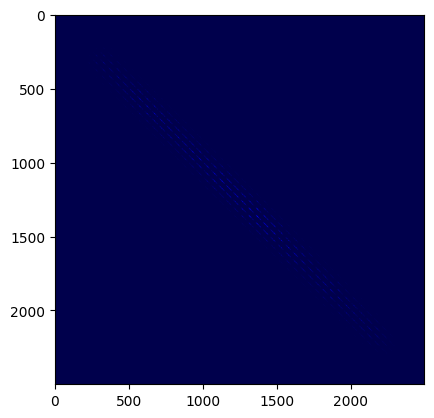

In [ ]:
C_nm_repeated = C_nm_repeated / np.mean(r_mean)
#S_rwa = r * onBarImage
plt.imshow(C_nm_repeated, cmap='seismic')
plt.show()

In [ ]:
D,V = np.linalg.eig(C_nm_repeated)

2.2558664146960236e-16


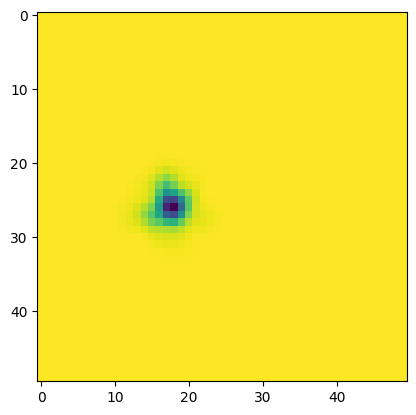

0.00023324294511737188


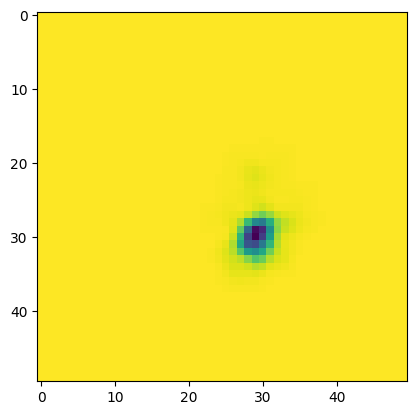

In [ ]:
reshapedEigenvector1 = V[:,0].reshape([50,50])
print(np.max(np.real(reshapedEigenvector1)))
plt.imshow(np.real(reshapedEigenvector1), vmin=np.min(np.real(reshapedEigenvector1)), vmax=np.max(np.real(reshapedEigenvector1)))
plt.show()
reshapedEigenvector2 = V[:,1].reshape([50,50])
print(np.max(np.real(reshapedEigenvector2)))
plt.imshow(np.real(reshapedEigenvector2), vmin=np.min(np.real(reshapedEigenvector2)), vmax=np.max(np.real(reshapedEigenvector2)))
plt.show()

In [ ]:
# calculate the response weighted average covariance using the white noise stimulus
r_mean = []
nRepeats = 25000
C_nm_repeated = np.zeros([2500,2500])
for k in range(nRepeats):
  whiteNoiseImage = WhiteNoise(50)
  r = MysteriousNeuron2(whiteNoiseImage)
  r_mean.append(r)
  # reshape image into vector
  onBarImageVector = whiteNoiseImage.reshape([50*50,1])
  C_nm = np.zeros([50*50,50*50])
  C_nm_mean = np.zeros([50*50,50*50])
  # calculate cross correlation
  C_nm = np.matmul(onBarImageVector, onBarImageVector.transpose())
  C_nm_mean = C_nm * r
  C_nm_repeated = C_nm_repeated + C_nm_mean


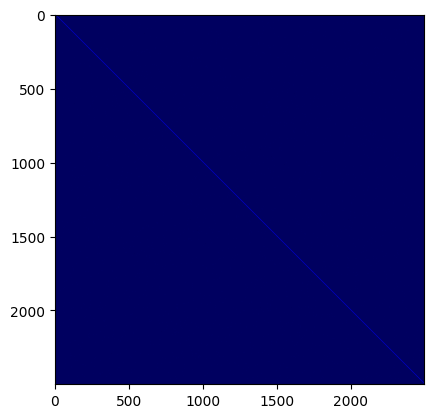

In [ ]:
C_nm_repeated = C_nm_repeated / np.mean(r_mean)
plt.imshow(C_nm_repeated, cmap='seismic')
plt.show()

In [ ]:
# calculate the eigenvalues (D) and eigenvectors (V) for the white noise stimulus of MN2
D,V = np.linalg.eig(C_nm_repeated)

0.07029582009036787


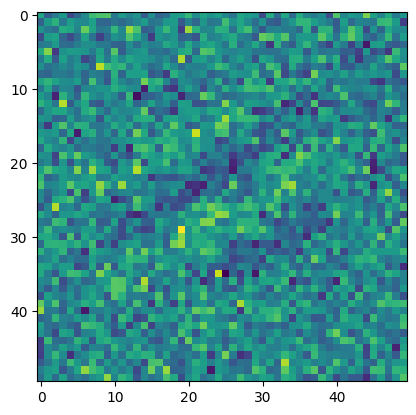

0.0709462205202202


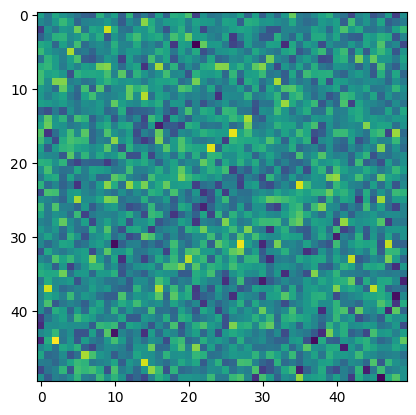

In [ ]:
# reshape 1st and 2nd eigenvectors into square images
reshapedEigenvector1 = V[:,0].reshape([50,50])
print(np.max(np.real(reshapedEigenvector1)))
plt.imshow(np.real(reshapedEigenvector1), vmin=np.min(np.real(reshapedEigenvector1)), vmax=np.max(np.real(reshapedEigenvector1)))
plt.show()
reshapedEigenvector2 = V[:,1].reshape([50,50])
print(np.max(np.real(reshapedEigenvector2)))
plt.imshow(np.real(reshapedEigenvector2), vmin=np.min(np.real(reshapedEigenvector2)), vmax=np.max(np.real(reshapedEigenvector2)))
plt.show()